In [1]:
import pickle
import pandas as pd
from funcoes_ajuda import descritiva, relatorio_missing, \
    diagnóstico, avalia_clf
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, \
    StratifiedKFold, GridSearchCV
from sklearn.metrics import roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
titanic = pd.read_pickle('/home/usp-ds-arnem/data/aula4/titanic1.pkl')

titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   survived    891 non-null    int64  
 1   pclass      891 non-null    int64  
 2   age         891 non-null    float64
 3   sibsp       891 non-null    int64  
 4   parch       891 non-null    int64  
 5   fare        891 non-null    float64
 6   sex_male    891 non-null    bool   
 7   embarked_Q  891 non-null    bool   
 8   embarked_S  891 non-null    bool   
dtypes: bool(3), float64(2), int64(4)
memory usage: 44.5 KB


In [3]:
relatorio_missing(titanic)

Número de linhas: 891 | Número de colunas: 9


,Pct_missing,Freq_missing
survived,0.0%,0
pclass,0.0%,0
age,0.0%,0
sibsp,0.0%,0
parch,0.0%,0
fare,0.0%,0
sex_male,0.0%,0
embarked_Q,0.0%,0
embarked_S,0.0%,0


In [13]:
features = list(titanic.columns)
label = 'survived'
features.remove(label)

X = titanic[features]
y = titanic[label]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42
                                                    )

In [15]:
dc_tree1 = DecisionTreeClassifier().fit(X_train, y_train)
y_pred = dc_tree1.predict(X_test)
roc_auc_score(y_test, y_pred)


0.7771557271557272

In [16]:
pd.crosstab(y_test, y_pred, rownames=['Real'], colnames=['Predito'])

Predito,0,1
Real,,
0,88,17
1,21,53


In [17]:
path = dc_tree1.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

In [19]:
ginis = []
for ccp_alpha in ccp_alphas:
    dc_tree = DecisionTreeClassifier(ccp_alpha=ccp_alpha)
    dc_tree.fit(X_train, y_train)
    y_pred = dc_tree.predict(X_test)
    auc = roc_auc_score(y_test, y_pred)
    gini = auc*2-1
    ginis.append(gini)

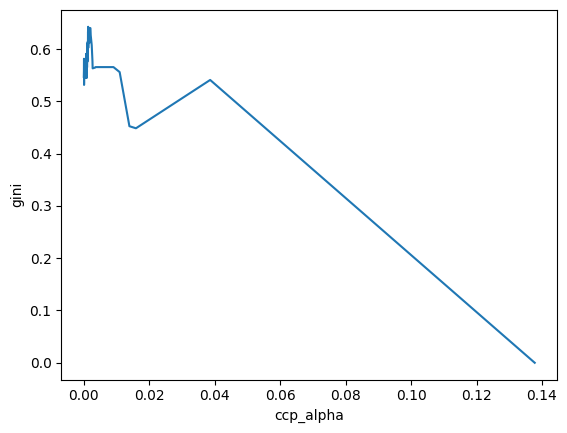

In [20]:
results = pd.DataFrame({'ccp_alpha': ccp_alphas,
                        'gini': ginis})

sns.lineplot(data=results, x='ccp_alpha', y='gini')
plt.show()

In [24]:
max_result = results[results['gini'] == results['gini'].max()]
ccp_max = max_result['ccp_alpha'].values[0]

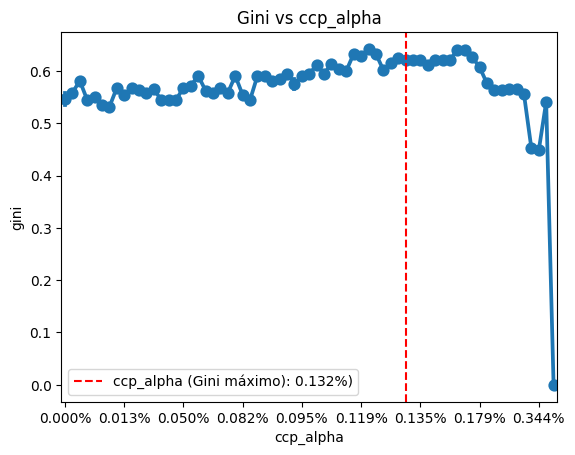

In [25]:
passo = 8

fig, ax = plt.subplots(1)
sns.pointplot(data=results, x='ccp_alpha', y='gini', ax=ax)
x_ticks = ax.get_xticks()[::passo]
x_ticks_labels = [f'{x:.3%}' for x in ccp_alphas[::passo]]
ax.set_xticks(x_ticks, x_ticks_labels)
ax.set_title('Gini vs ccp_alpha')
plt.axvline(x=max_result.index[0], color='red', linestyle='--',
            label=f'ccp_alpha (Gini máximo): {ccp_max:.3%})')
ax.legend()
plt.show()


In [26]:
dc_tree2 = DecisionTreeClassifier(ccp_alpha=ccp_max).fit(X_train, y_train)
y_pred = dc_tree2.predict(X_test)
roc_auc_score(y_test, y_pred)

0.8164736164736165

Improvement!!!

In [27]:
param_grid = {'criterion': ['gini', 'entropy'],
              'ccp_alpha': ccp_alphas,
              'max_depth': [None, 5, 10, 15, 20],
              'min_samples_split': [2, 5, 10],
              'min_samples_leaf': [1, 2, 4],
              'max_features': ['auto', 'sqrt', 'log2', None]
              }

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

clf = DecisionTreeClassifier(random_state=42)

grid_search = GridSearchCV(clf, param_grid, 
                           scoring='roc_auc',
                           cv=skf, 
                           n_jobs=-1,
                           return_train_score=True)

In [ ]:
grid_search.fit(X_train, y_train)

/root/.local/share/virtualenvs/usp-ds-arnem-_IUna4d0/lib/python3.11/site-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
64800 fits failed out of a total of 259200.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
27386 fits failed with the following error:
Traceback (most recent call last):
  File "/root/.local/share/virtualenvs/usp-ds-arnem-_IUna4d0/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/root/.local/share/virtualenvs/usp-ds-arnem-_IUna4d0/lib/python3.11/site-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/root/.local/share/virtualenvs/usp-ds-arnem-_IUna4d

0.8595384039828483
DecisionTreeClassifier(ccp_alpha=0.0024122647015905434, max_depth=20,
                       max_features='log2', min_samples_split=5,
                       random_state=42)
{'ccp_alpha': 0.0024122647015905434, 'criterion': 'gini', 'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5}


/root/.local/share/virtualenvs/usp-ds-arnem-_IUna4d0/lib/python3.11/site-packages/sklearn/model_selection/_search.py:1052: UserWarning: One or more of the test scores are non-finite: [       nan        nan        nan ... 0.76572455 0.76572455 0.76572455]
  warnings.warn(
/root/.local/share/virtualenvs/usp-ds-arnem-_IUna4d0/lib/python3.11/site-packages/sklearn/model_selection/_search.py:1052: UserWarning: One or more of the train scores are non-finite: [       nan        nan        nan ... 0.76561581 0.76561581 0.76561581]
  warnings.warn(


In [ ]:
print(f'best score: {grid_search.best_score_}')
print(f'best estimator: {grid_search.best_estimator_}')
print(f'best params: {grid_search.best_params_}')

best score: 0.8595384039828483
best estimator: DecisionTreeClassifier(ccp_alpha=0.0024122647015905434, max_depth=20,
                       max_features='log2', min_samples_split=5,
                       random_state=42)
best params: {'ccp_alpha': 0.0024122647015905434, 'criterion': 'gini', 'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5}


In [34]:
results = pd.DataFrame(grid_search.cv_results_)
results[['mean_test_score', 'std_test_score', 'mean_train_score', 'std_train_score', 'params']].sort_values('mean_test_score', ascending=False)
results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_ccp_alpha,param_criterion,param_max_depth,param_max_features,param_min_samples_leaf,param_min_samples_split,...,split2_train_score,split3_train_score,split4_train_score,split5_train_score,split6_train_score,split7_train_score,split8_train_score,split9_train_score,mean_train_score,std_train_score
0,0.001352,0.000066,0.000000,0.000000,0.00000,gini,NaN,auto,1,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.001139,0.000259,0.000000,0.000000,0.00000,gini,NaN,auto,1,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.000637,0.000099,0.000000,0.000000,0.00000,gini,NaN,auto,1,10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.000697,0.000113,0.000000,0.000000,0.00000,gini,NaN,auto,2,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.000601,0.000060,0.000000,0.000000,0.00000,gini,NaN,auto,2,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25915,0.004492,0.001145,0.003674,0.000667,0.13778,entropy,20.0,None,2,5,...,0.759963,0.763655,0.761525,0.761525,0.769424,0.765249,0.7632,0.770648,0.765616,0.004035
25916,0.004378,0.000620,0.004190,0.000963,0.13778,entropy,20.0,None,2,10,...,0.759963,0.763655,0.761525,0.761525,0.769424,0.765249,0.7632,0.770648,0.765616,0.004035
25917,0.004277,0.000700,0.003505,0.000434,0.13778,entropy,20.0,None,4,2,...,0.759963,0.763655,0.761525,0.761525,0.769424,0.765249,0.7632,0.770648,0.765616,0.004035
25918,0.003756,0.000635,0.003288,0.000261,0.13778,entropy,20.0,None,4,5,...,0.759963,0.763655,0.761525,0.761525,0.769424,0.765249,0.7632,0.770648,0.765616,0.004035


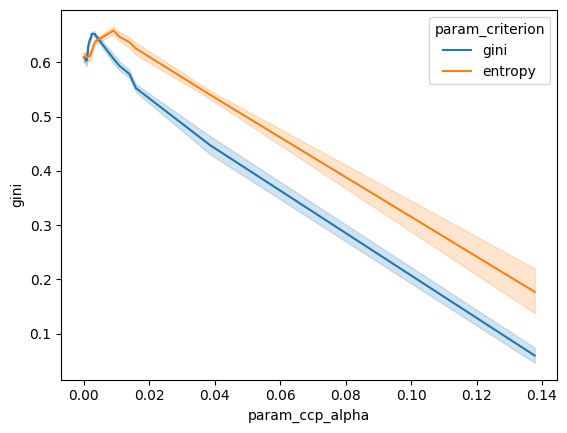

In [35]:
results['gini'] = results['mean_test_score']*2-1
sns.lineplot(data=results, x='param_ccp_alpha', y='gini', hue='param_criterion')
plt.show()


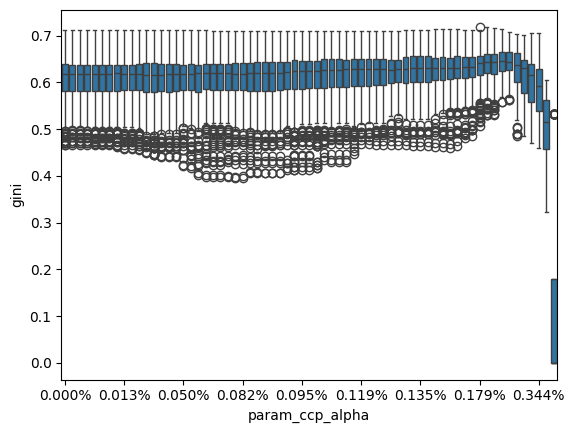

In [38]:
fig, ax = plt.subplots(1)

results['gini'] = results.mean_test_score*2-1
sns.boxplot(data=results, 
             x=results['param_ccp_alpha'].astype('str'), 
             y='gini',
             ax=ax)
passo = 8
x_ticks = ax.get_xticks()[::passo]
x_tick_labels = [f'{x:.3%}' for x in ccp_alphas[::passo]]
ax.set_xticks(x_ticks, x_tick_labels)
plt.show()

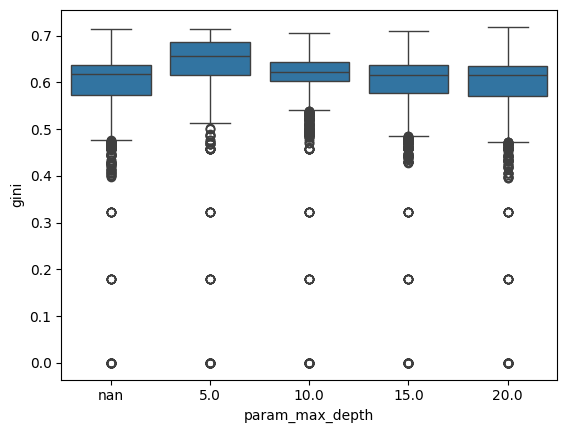

In [39]:
sns.boxplot(data=results, 
             x=results['param_max_depth'].astype('str'), 
             y='gini')
plt.show()

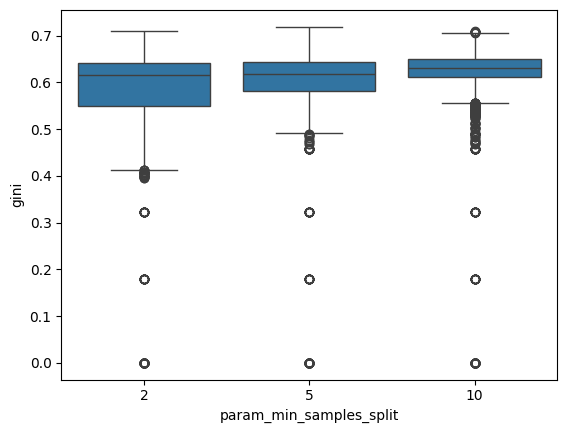

In [40]:
sns.boxplot(data=results, 
             x=results['param_min_samples_split'].astype('str'), 
             y='gini')
plt.show()

Final Model

In [41]:
best_clf = grid_search.best_estimator_
prob = best_clf.predict_proba(X_test)[:, 1]
y_pred = best_clf.predict(X_test)

test_score = best_clf.score(X_test, y_test)
auc = roc_auc = roc_auc_score(y_test, prob)
gini = 2*roc_auc-1

print(f'Test score: {test_score:.3%}')
print(f'AUC: {auc:.3%}')
print(f'Gini: {gini:.3%}')

Test score: 81.006%
AUC: 88.333%
Gini: 76.667%


In [43]:
df_test = X_test.copy()
df_test['y'] = y_test
df_test['prob'] = prob
df_test['y_pred'] = y_pred

df_test.head()

,pclass,age,sibsp,parch,fare,sex_male,embarked_Q,embarked_S,y,prob,y_pred
709,3,29.699118,1,1,15.2458,True,False,False,1,0.196429,0
439,2,31.000000,0,0,10.5000,True,False,True,0,0.098592,0
840,3,20.000000,0,0,7.9250,True,False,True,0,0.118750,0
720,2,6.000000,0,1,33.0000,False,False,True,1,0.955224,1
39,3,14.000000,1,0,11.2417,False,False,False,1,0.620690,1


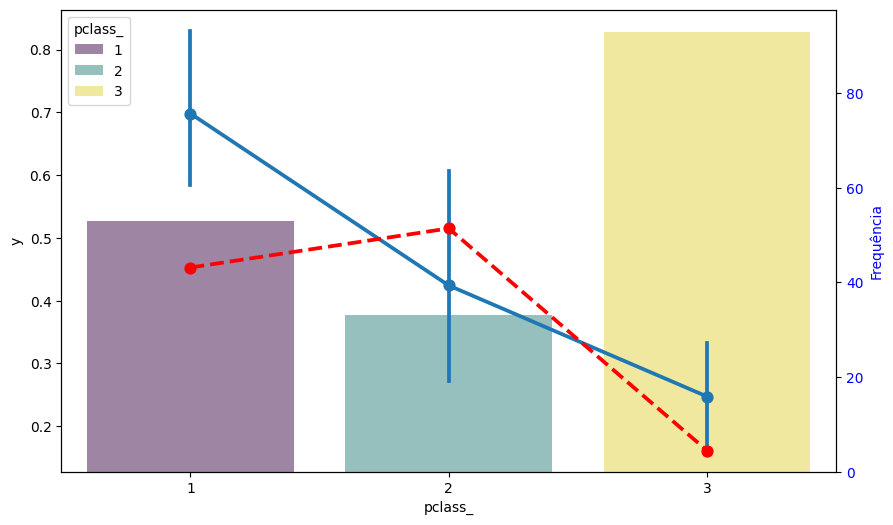

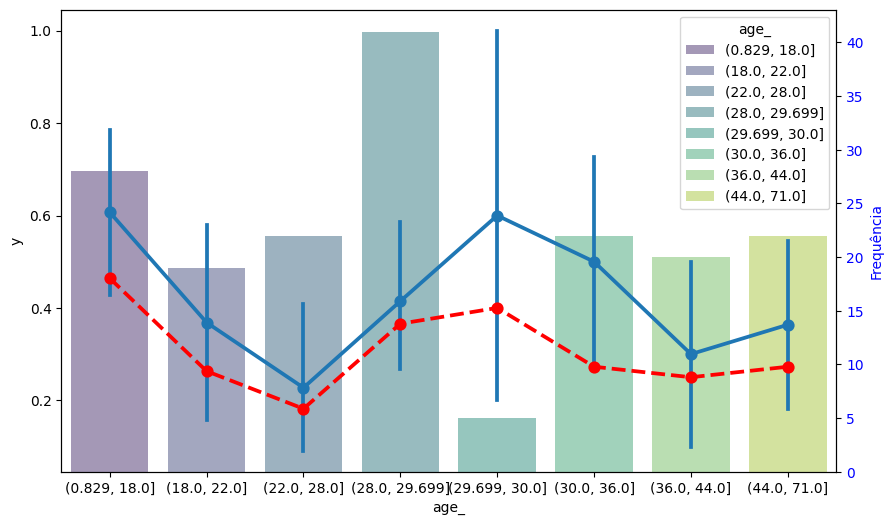

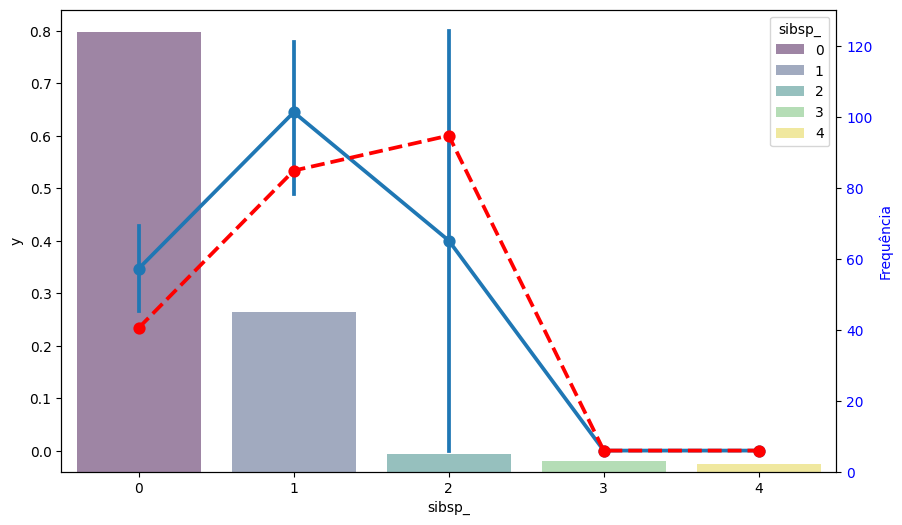

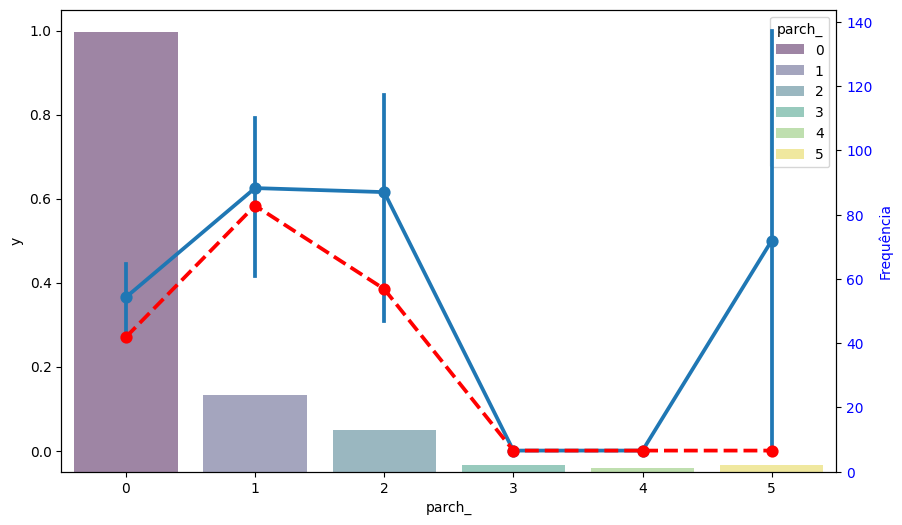

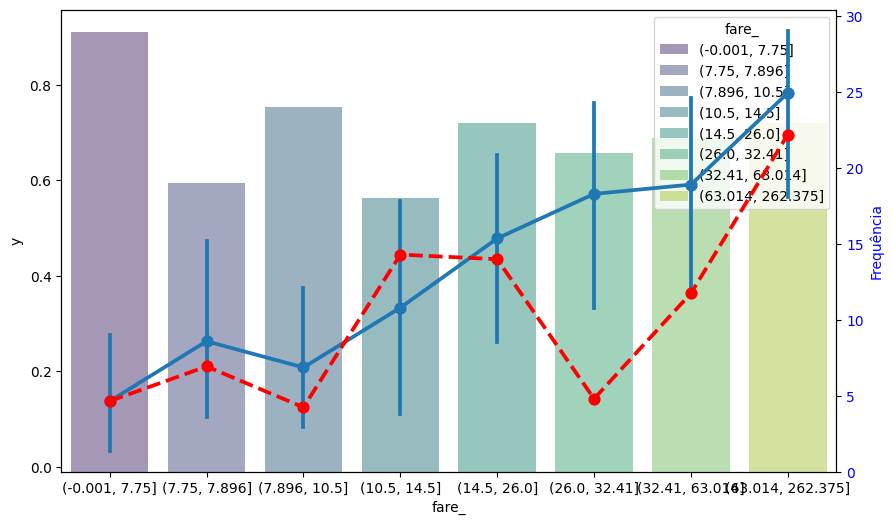

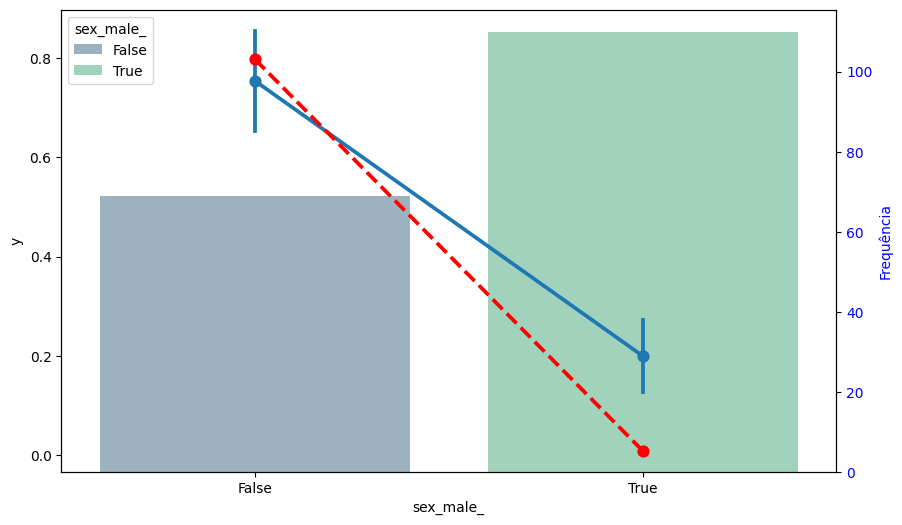

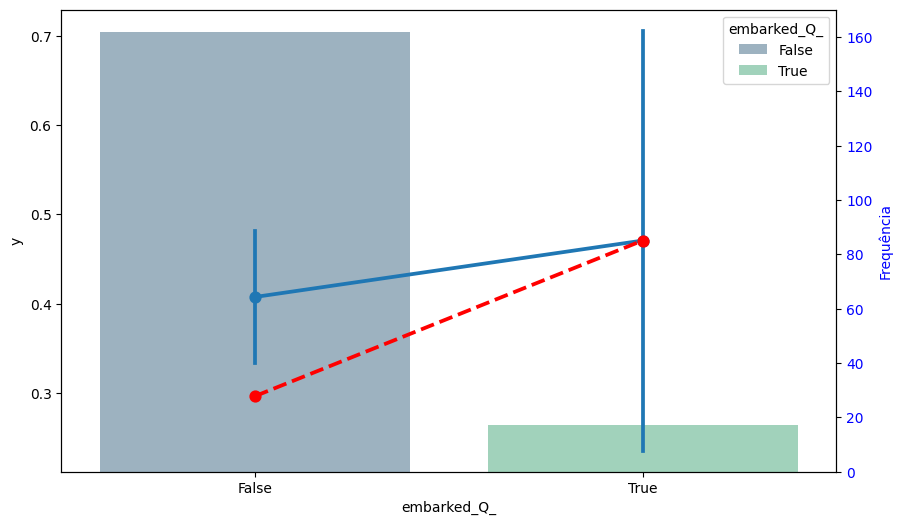

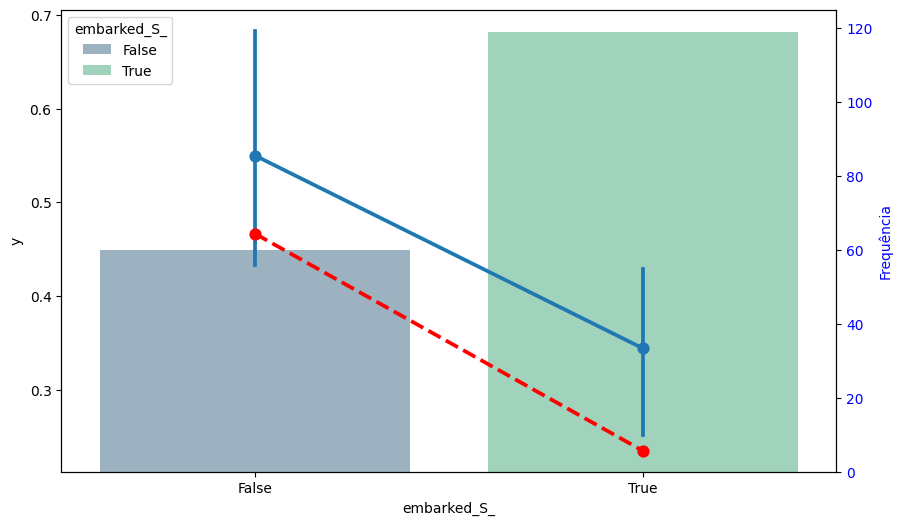

In [45]:
for var in X_test.columns:
    diagnóstico(df_test, var, vresp='y', pred='y_pred', max_classes=8)


In [46]:
# save the model to pickle
with open('/home/usp-ds-arnem/data/aula4/best_clf.pkl', 'wb') as f:
    pickle.dump(best_clf, f)